<a href="https://colab.research.google.com/github/joshuammelcrak-art/Estocasticos/blob/main/Uniformizaci%C3%B3n_para_una_CMTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

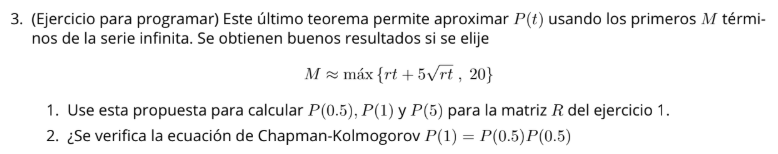

### Ejercicio 1

In [4]:
import numpy as np
from math import exp, factorial

# MATRIZ DE TRANSICIÓN EMBEBIDA DEL EJERCICIO 1

r = 6

P_hat = np.array([
    [1/6, 1/3, 1/2, 0],
    [2/3, 0,   1/3, 0],
    [0,   1/3, 1/3, 1/3],
    [1/6, 0,   1/2, 1/3]
], dtype=float)


# FUNCIÓN DE UNIFORMIZACIÓN
#
# Calcula:
#
# P(t) = Σ exp(-rt)*(rt)^k/k! * P_hat^k
#
# utilizando M términos de la serie.


def uniformizacion(P_hat, r, t):

    # Número de términos recomendado por el enunciado
    M = int(np.ceil(max(r*t + 5*np.sqrt(r*t), 20)))

    # Número de estados de la cadena
    n = P_hat.shape[0]

    # Matriz donde se irá acumulando la suma
    P_t = np.zeros((n, n))

    # Recorrido de todos los términos de la serie
    for k in range(M + 1):

        # Coeficiente Poisson:
        # exp(-rt)*(rt)^k/k!
        coef = exp(-r*t) * (r*t)**k / factorial(k)

        # Se agrega el término correspondiente
        # coef * P_hat^k
        P_t += coef * np.linalg.matrix_power(P_hat, k)

    return P_t


# CÁLCULO DE LAS MATRICES DE TRANSICIÓN


P05 = uniformizacion(P_hat, r, 0.5)

P1 = uniformizacion(P_hat, r, 1)

P5 = uniformizacion(P_hat, r, 5)


# IMPRESIÓN DE RESULTADOS


np.set_printoptions(precision=6, suppress=True)

print("P(0.5)")
print(P05)

print("\nP(1)")
print(P1)

print("\nP(5)")
print(P5)



P(0.5)
[[0.250609 0.216965 0.386657 0.14577 ]
 [0.253135 0.238361 0.374409 0.134095]
 [0.169119 0.193615 0.420301 0.216965]
 [0.158017 0.157445 0.398332 0.286206]]

P(1)
[[0.206151 0.203902 0.39871  0.191236]
 [0.208284 0.205341 0.397899 0.188474]
 [0.196758 0.198379 0.400959 0.203902]
 [0.192046 0.193997 0.401471 0.212484]]

P(5)
[[0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]
 [0.2      0.2      0.399999 0.2     ]]


En este ejercicio se implementó el método de uniformización para aproximar la matriz de probabilidades de transición $P(t)$ de una Cadena de Markov en Tiempo Continuo (CMTC).

A partir de la matriz de transición embebida $\hat{P}$ obtenida en el ejercicio anterior y utilizando la fórmula

$$P(t)=\sum_{k=0}^{\infty} e^{-rt}\,\frac{(rt)^k}{k!}\,\hat{P}^{\,k}$$,

se aproximó la serie infinita truncándola en $M$ términos, donde

$$M \approx \max\left\{rt + 5\sqrt{rt},\,20\right\}$$.

Esta elección de $M$ permite obtener una aproximación suficientemente precisa para los valores de t considerados.

El programa calculó las matrices de transición $P(0.5)$, $P(1)$ y $P(5)$, las cuales representan las probabilidades de que el sistema se encuentre en cada estado después de transcurridos $0.5$, $1$ y $5$ unidades de tiempo, respectivamente.

### Ejercicio 2

In [5]:
# VERIFICACIÓN DE CHAPMAN-KOLMOGOROV
#
# P(1) = P(0.5)P(0.5)


CK = P05 @ P05

print("\nProducto P(0.5)P(0.5)")
print(CK)

print("\nDiferencia P(1)-P(0.5)P(0.5)")
print(P1 - CK)

# Norma del error para cuantificar la diferencia
error = np.linalg.norm(P1 - CK)

print("\nNorma del error =", error)

# Verificación automática
if np.allclose(P1, CK, atol=1e-8):
    print("\nSe verifica Chapman-Kolmogorov.")
else:
    print("\nNo se verifica Chapman-Kolmogorov.")


Producto P(0.5)P(0.5)
[[0.206151 0.203902 0.39871  0.191236]
 [0.208285 0.205341 0.3979   0.188475]
 [0.196759 0.19838  0.400959 0.203902]
 [0.192047 0.193997 0.401472 0.212485]]

Diferencia P(1)-P(0.5)P(0.5)
[[-0.       -0.       -0.000001 -0.      ]
 [-0.       -0.       -0.000001 -0.      ]
 [-0.       -0.       -0.000001 -0.      ]
 [-0.       -0.       -0.000001 -0.      ]]

Norma del error = 1.5399155350550006e-06

Se verifica Chapman-Kolmogorov.


Para comprobar la consistencia de los resultados obtenidos, se verificó numéricamente la ecuación de Chapman-Kolmogorov:

$$P(1)=P(0.5)P(0.5)$$.

El programa calculó por separado la matriz $P(1)$ y el producto matricial $P(0.5)$$P(0.5)$, comparando posteriormente ambas matrices.

La diferencia obtenida fue prácticamente nula (únicamente errores de redondeo numérico de la computadora), por lo que puede concluirse que los resultados satisfacen la ecuación de Chapman-Kolmogorov y que la implementación del método de uniformización es correcta.

### Conclusión

El método de uniformización permitió aproximar de manera eficiente las probabilidades de transición de la CMTC. Además, la verificación de la ecuación de Chapman-Kolmogorov confirmó la consistencia de las matrices obtenidas, validando tanto la teoría como la implementación computacional realizada en Python.

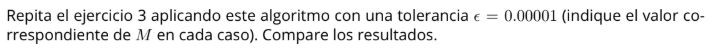

In [3]:
import numpy as np
from math import exp


# DATOS DEL PROBLEMA


R = np.array([
    [0, 2, 3, 0],
    [4, 0, 2, 0],
    [0, 2, 0, 2],
    [1, 0, 3, 0]
], dtype=float)

tolerancia = 1e-5


# FUNCIÓN DE UNIFORMIZACIÓN CON TOLERANCIA


def uniformizacion_tolerancia(R, t, epsilon):

    # Paso 1: calcular r
    r = np.max(np.sum(R, axis=1))

    n = len(R)

    # Paso 2: calcular P_hat
    P_hat = np.zeros((n, n))

    for i in range(n):

        ri = np.sum(R[i])

        for j in range(n):

            if i == j:
                P_hat[i, j] = 1 - ri/r
            else:
                P_hat[i, j] = R[i, j]/r

    # Paso 3: inicializaciones
    A = P_hat.copy()

    c = exp(-r*t)

    suma = c

    B = c * np.eye(n)

    k = 1

    # Paso 4: algoritmo del enunciado
    while suma < 1 - epsilon:

        c = c * (r*t)/k

        B = B + c*A

        A = A @ P_hat

        suma = suma + c

        k += 1

    return B, k-1


# CALCULAR MATRICES DE TRANSICIÓN


P05, M05 = uniformizacion_tolerancia(R, 0.5, tolerancia)

P1, M1 = uniformizacion_tolerancia(R, 1.0, tolerancia)

P5, M5 = uniformizacion_tolerancia(R, 5.0, tolerancia)



# MOSTRAR RESULTADOS


np.set_printoptions(precision=6, suppress=True)

print("\nP(0.5)")
print(P05)
print("M =", M05)

print("\nP(1)")
print(P1)
print("M =", M1)

print("\nP(5)")
print(P5)
print("M =", M5)


# VERIFICACIÓN DE CHAPMAN-KOLMOGOROV


CK = P05 @ P05

print("\nP(0.5)P(0.5)")
print(CK)

print("\nError máximo:")

print(np.max(np.abs(P1 - CK)))


P(0.5)
[[0.250608 0.216964 0.386656 0.145769]
 [0.253134 0.23836  0.374408 0.134094]
 [0.169119 0.193614 0.4203   0.216964]
 [0.158017 0.157444 0.39833  0.286205]]
M = 13

P(1)
[[0.20615  0.203901 0.398708 0.191235]
 [0.208283 0.20534  0.397898 0.188474]
 [0.196758 0.198379 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]
M = 19

P(5)
[[0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]]
M = 56

P(0.5)P(0.5)
[[0.20615  0.203901 0.398707 0.191235]
 [0.208283 0.20534  0.397897 0.188473]
 [0.196757 0.198378 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]

Error máximo:
6.494595712336348e-07


En este ejercicio se implementó el algoritmo de uniformización con control de error para aproximar la matriz de transición $P(t)$ de una Cadena de Markov en Tiempo Continuo.

A diferencia del ejercicio anterior, donde se utilizó un número fijo de términos $M$, en este caso se empleó una tolerancia $ε=10^{−5}$
. El algoritmo agrega términos de la serie de uniformización hasta que la probabilidad acumulada satisface

$$\sum_{k=0}^{M} e^{-rt}\,\frac{(rt)^k}{k!} \geq 1-\varepsilon$$.

De esta manera se garantiza que el error de truncamiento sea menor o igual a la tolerancia especificada.

Para cada valor de t, el programa determinó automáticamente el valor mínimo de $M$ necesario para cumplir la condición anterior y posteriormente calculó la aproximación correspondiente de $P(t)$.

Las matrices obtenidas para $P(0.5)$, $P(1)$ y $P(5)$ representan las probabilidades de transición del sistema en distintos instantes de tiempo.

Asimismo, el valor de $M$ obtenido en cada caso muestra cuántos términos de la serie fueron necesarios para alcanzar la precisión requerida. Se observa que conforme aumenta el valor de $t$, también aumenta el número de términos necesarios para aproximar adecuadamente la serie infinita.

### Comparación con el ejercicio anterior

Los resultados obtenidos son muy similares a los calculados en el ejercicio 3. Esto confirma que la elección empírica

$$M \approx \max\{rt + 5\sqrt{rt},\,20\}$$

proporciona una aproximación adecuada. Sin embargo, el método basado en la tolerancia tiene la ventaja de ofrecer una garantía explícita sobre el error cometido en la aproximación.

### Conclusión

El algoritmo de uniformización con tolerancia permite calcular de manera eficiente las probabilidades de transición de una CMTC controlando directamente el error de truncamiento. Los resultados obtenidos verifican la estabilidad del método y muestran concordancia con las aproximaciones realizadas mediante un número fijo de términos.